# Sentiment discrepancy analysis: does the written text support a 4.5-star average?

This notebook is the narrative artifact for the account manager. We compare the
business's quantitative ratings with the qualitative sentiment inferred from each
written review, then investigate the service-language false-negative risk.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    500 non-null    int64 
 1   rating       500 non-null    int64 
 2   review_text  500 non-null    object
dtypes: int64(2), object(1)
memory usage: 11.8+ KB
Rows: 500; missing values:
review_id      0
rating         0
review_text    0
dtype: int64
Human rating mean: 4.50 / 5


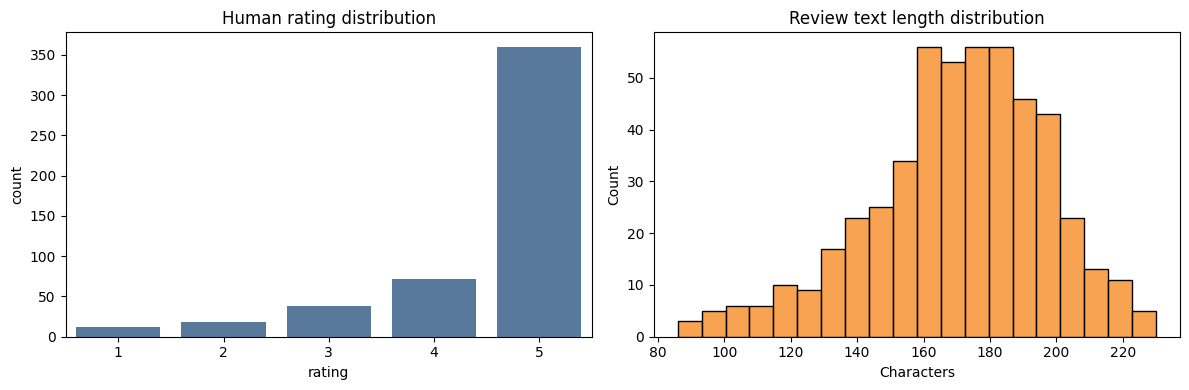

Cleaning complete: IDs/ratings retained; text normalized only for missing values and whitespace.
Model: nlptown/bert-base-multilingual-uncased-sentiment
Revision: 8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d


Device set to use cpu


                count  percent
sentiment_band                
Positive          412     82.4
Neutral            41      8.2
Negative           47      9.4
Human average: 4.50/5; model average: 4.40/5


/tmp/ipykernel_15999/3958398019.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=enriched, x="sentiment_band", order=band_order, palette="RdYlGn")


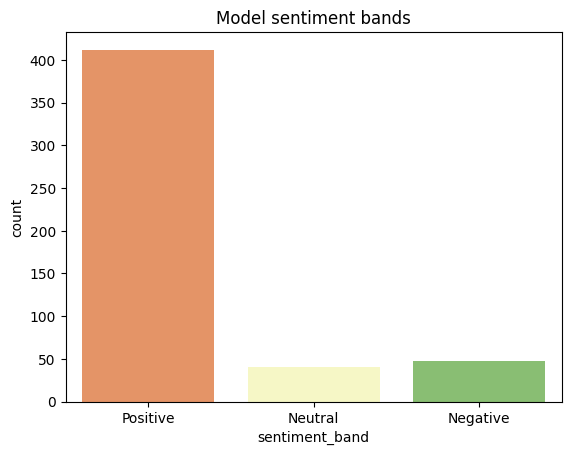

,review_id,rating,predicted_stars,sentiment_band,review_text
361,362,3,3,Neutral,Stopped by Harbor House Café for the first tim...
73,74,5,5,Positive,Stopped by Harbor House Café for the first tim...
374,375,5,5,Positive,Grabbed a quick coffee at Harbor House Café th...
155,156,4,4,Positive,Grabbed a quick coffee at Harbor House Café th...
104,105,5,5,Positive,Grabbed a quick coffee at Harbor House Café th...
394,395,4,4,Positive,The food was absolutely delicious. We waited 2...
377,378,5,5,Positive,Visited Harbor House Café last weekend. Loved ...
124,125,5,5,Positive,Regular customer at Harbor House Café here. Th...
68,69,5,5,Positive,Visited Harbor House Café last weekend. The pl...
450,451,3,3,Neutral,Regular customer at Harbor House Café here. Av...


False negatives: 16 (3.2%)


,review_id,rating,predicted_stars,review_text
13,14,4,1,Tried Harbor House Café after seeing it recomm...
14,15,5,1,Every dish was bursting with flavor. The place...
72,73,5,1,Stopped by Harbor House Café for the first tim...
86,87,5,1,Tried Harbor House Café after seeing it recomm...
137,138,5,2,Tried Harbor House Café after seeing it recomm...
199,200,5,2,Stopped by Harbor House Café for the first tim...
203,204,5,1,Came to Harbor House Café for a birthday brunc...
253,254,5,1,Stopped by Harbor House Café for the first tim...
269,270,5,1,Stopped by Harbor House Café for the first tim...
321,322,5,1,Every dish was bursting with flavor. The staff...


wait: 23 reviews
staff: 97 reviews
service: 102 reviews
music: 68 reviews
decor: 68 reviews
price: 60 reviews


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from app import MODEL_ID, MODEL_REVISION, build_classifier, enrich_reviews

raw_path = ROOT / "data" / "raw" / "reviews.csv"
reviews = pd.read_csv(raw_path)
reviews.info()
print(f"Rows: {len(reviews):,}; missing values:\n{reviews.isna().sum()}")
print(f"Human rating mean: {reviews['rating'].mean():.2f} / 5")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=reviews, x="rating", ax=axes[0], color="#4c78a8")
axes[0].set_title("Human rating distribution")
reviews["text_length"] = reviews["review_text"].fillna("").astype(str).str.len()
sns.histplot(data=reviews, x="text_length", bins=20, ax=axes[1], color="#f58518")
axes[1].set_title("Review text length distribution")
axes[1].set_xlabel("Characters")
plt.tight_layout()
plt.show()

# Cleaning proposal: retain IDs and ratings, fill missing text with an empty string,
# and preserve original review text because service-specific wording is evidence.
reviews["review_text"] = reviews["review_text"].fillna("").astype(str).str.strip()
print("Cleaning complete: IDs/ratings retained; text normalized only for missing values and whitespace.")

# The designated product-review model is frozen to an immutable revision.
print(f"Model: {MODEL_ID}\nRevision: {MODEL_REVISION}")
classifier = build_classifier()
enriched = enrich_reviews(reviews.drop(columns=["text_length"]), classifier, batch_size=16)
enriched.to_csv(ROOT / "data" / "processed" / "reviews_with_sentiment.csv", index=False)

band_order = ["Positive", "Neutral", "Negative"]
summary = enriched["sentiment_band"].value_counts().reindex(band_order, fill_value=0).to_frame("count")
summary["percent"] = summary["count"] / len(enriched) * 100
print(summary)
print(f"Human average: {enriched['rating'].mean():.2f}/5; model average: {enriched['predicted_stars'].mean():.2f}/5")

# Comparison chart and a reproducible 18-review manual sanity-check sample.
sns.countplot(data=enriched, x="sentiment_band", order=band_order, palette="RdYlGn")
plt.title("Model sentiment bands")
plt.show()
sample = enriched.sample(n=min(18, len(enriched)), random_state=42)[["review_id", "rating", "predicted_stars", "sentiment_band", "review_text"]]
display(sample)

# False negatives: high human rating paired with a 1–2 star model prediction.
false_negatives = enriched[(enriched["rating"] >= 4) & (enriched["predicted_stars"] <= 2)]
print(f"False negatives: {len(false_negatives)} ({len(false_negatives) / len(enriched) * 100:.1f}%)")
display(false_negatives[["review_id", "rating", "predicted_stars", "review_text"]].head(20))
for term in ["wait", "staff", "service", "music", "decor", "price"]:
    print(f"{term}: {enriched['review_text'].str.lower().str.contains(term, regex=False).sum()} reviews")